# Topic Modeling Locally in VS Code

This notebook runs locally in VS Code and reads the dissertation dataset from a file in the same folder as the notebook.


## Notebook Overview

In this notebook, I analyze the non-English language records in the CUNY Graduate Center dissertation dataset. Because Spanish is by far the largest non-English group, I focus the topic-modeling portion of the analysis on dissertations classified as Spanish-language.

I checked the language of the available abstracts and found that most abstracts for Spanish-language dissertations are written in English. For consistency, I restricted the topic model to Spanish-language dissertations with English-language abstracts. I preprocessed these abstracts by removing stopwords, shortening words through stemming, and converting the texts into a bag-of-words format.

Finally, I trained an LDA topic model with five topics, inspected the top words and strongest matching dissertation abstracts for each topic, and assigned interpretive labels to the topics. The resulting topics describe major themes in the Spanish-language dissertation subset, including translation, Hispanic literary history, cultural criticism, politics, nation, sociolinguistics, and Latin American literary studies.

In [1]:
import sys
print(sys.executable)

%pip install numbers-parser

/opt/anaconda3/bin/python
Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import importlib.util

print(sys.executable)

mods = ["pandas", "numpy", "matplotlib", "gensim", "nltk", "sklearn", "numbers_parser", "openpyxl", "scipy"]

for m in mods:
    print(m, "OK" if importlib.util.find_spec(m) else "MISSING")

/opt/anaconda3/bin/python
pandas OK
numpy OK
matplotlib OK
gensim OK
nltk OK
sklearn OK
numbers_parser OK
openpyxl OK
scipy OK


In [3]:
%pip install -q pandas numpy matplotlib gensim nltk scikit-learn numbers-parser openpyxl

print('Packages installed.')


Note: you may need to restart the kernel to use updated packages.
Packages installed.


Choose a local dataset source

Keep `gc_dissertations_combined_v2.numbers` in the same folder as this notebook, or change `DATA_PATH` to the correct local path.


In [4]:
from pathlib import Path

DATA_SOURCE = "local"
DATA_PATH = Path("gc_dissertations_combined_v2.numbers")

# Change this after the data-loading cell prints your column names.
TEXT_COLUMN = "abstract"

# Use the first sheet and first table in the Numbers file.
NUMBERS_SHEET_INDEX = 0
NUMBERS_TABLE_INDEX = 0

print("Data source selected:", DATA_SOURCE)
print("Working directory:", Path.cwd())
print("Data path:", DATA_PATH)
print("Exists:", DATA_PATH.exists())


Data source selected: local
Working directory: /Users/boryana/Desktop/AI and ML
Data path: gc_dissertations_combined_v2.numbers
Exists: True


Basic Imports

In [5]:
import numpy as np
import pandas as pd
import gensim
from gensim import corpora
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim.models.coherencemodel import CoherenceModel
from nltk.stem import WordNetLemmatizer, SnowballStemmer
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt


Settings

In [6]:
np.random.seed(2026)
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download("stopwords")

english_stemmer = SnowballStemmer('english')
spanish_stemmer = SnowballStemmer("spanish")
ENGLISH_STOPWORDS = set(stopwords.words("english"))
SPANISH_STOPWORDS = set(stopwords.words("spanish"))

# model settings
NUM_TOPICS = 5
PASSES = 5
WORKERS = 2

# data settings
USE_SUBSET = False
DO_TESTING = True
# TRUNCATE_SIZE = 50000 don't want to accidentally truncate the Spanisg group of only 215 records. 
INSPECT_ROW = 4310

# dictionary settings
MAX_WORDS = 100000
MIN_WORDS = 15
MAX_PERCENTAGE = 0.5

print('Dependencies loaded.')


Dependencies loaded.


[nltk_data] Downloading package wordnet to /Users/boryana/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/boryana/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/boryana/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## Load data from local datasource

In [7]:
# Load data from the local datasource
try:
    DATA_PATH
except NameError:
    raise NameError("DATA_PATH is not defined. Ensure the cell defining DATA_PATH is executed.")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Could not find the dataset at {DATA_PATH.resolve()}")

suffix = DATA_PATH.suffix.lower()

if suffix == ".numbers":
    from numbers_parser import Document

    doc = Document(str(DATA_PATH))
    sheet = doc.sheets[NUMBERS_SHEET_INDEX]
    table = sheet.tables[NUMBERS_TABLE_INDEX]
    rows = table.rows(values_only=True)

    if not rows:
        raise ValueError("The selected Numbers table is empty.")

    data = pd.DataFrame(rows[1:], columns=rows[0])
    print(f"Loaded Numbers sheet={sheet.name!r}, table={table.name!r}")
elif suffix == ".csv":
    data = pd.read_csv(DATA_PATH)
elif suffix in {".xlsx", ".xls"}:
    data = pd.read_excel(DATA_PATH)
else:
    raise ValueError("Unsupported file type. Use .numbers, .csv, .xlsx, or .xls.")

# Clean up blank/unnamed columns that can come from spreadsheet exports.
data = data.dropna(axis=1, how="all")
data.columns = [str(col).strip() for col in data.columns]

print("Dataset loaded. Shape:", data.shape)
print("Columns:", list(data.columns))
print(data.head())
print("Missing values:\n", data.isna().sum())

if TEXT_COLUMN not in data.columns:
    raise KeyError(
        f"Text column {TEXT_COLUMN!r} not found. "
        f"Set TEXT_COLUMN in the datasource cell to one of: {list(data.columns)}"
    )

data_text = data[[TEXT_COLUMN]].copy()
data_text[TEXT_COLUMN] = data_text[TEXT_COLUMN].fillna("").astype(str)
data_text["index"] = data_text.index

documents = data_text
if USE_SUBSET:
    documents = data_text.truncate(before=0, after=TRUNCATE_SIZE)

print("Documents kept for analysis:", len(documents))
print(documents.head())


Loaded Numbers sheet='Sheet 1', table='gc_dissertations_combined_v2'
Dataset loaded. Shape: (18819, 26)
Columns: ['record_id', 'record_source', 'dup_group', 'has_duplicate', 'title', 'creator', 'year', 'program', 'program_coarse', 'program_source', 'program_raw', 'degree', 'degree_level', 'genre_raw', 'advisors', 'committee', 'keywords', 'n_keywords', 'abstract', 'abstract_wordcount', 'abstract_is_placeholder', 'language', 'institution', 'url', 'proquest_id', 'source_collection']
       record_id    record_source dup_group  has_duplicate  \
0  pq:AAI6508539  proquest_legacy      None            0.0   
1  pq:AAI6513027  proquest_legacy      None            0.0   
2  pq:AAI6609267  proquest_legacy      None            0.0   
3  pq:AAI6609268  proquest_legacy      None            0.0   
4  pq:AAI6609269  proquest_legacy      None            0.0   

                                               title  \
0  ENTRAPMENT AND LIBERATION IN JAMES JOYCE'S DED...   
1  RELATIONS BETWEEN MOTOR RES

## Research question 1: Language counts

In [8]:
language_counts = data["language"].value_counts(dropna=False)

print("All dissertation languages:")
print(language_counts)

non_english_counts = data.loc[
    data["language"].notna() & (data["language"] != "English"),
    "language"
].value_counts()

print("\nNon-English dissertation languages:")
print(non_english_counts)

All dissertation languages:
language
English                18545
Spanish                  215
French                    35
Italian                   12
German                     5
Portuguese                 2
Spanish and English        2
French and English         1
None                       1
Multiple languages         1
Name: count, dtype: int64

Non-English dissertation languages:
language
Spanish                215
French                  35
Italian                 12
German                   5
Portuguese               2
Spanish and English      2
French and English       1
Multiple languages       1
Name: count, dtype: int64


## Filter Spanish/English datasets

In [9]:
# Filter Spanish and English dissertations with usable abstracts

usable_data = data[
    data["abstract"].notna() &
    (data["abstract"].astype(str).str.strip() != "")
].copy()

spanish_data = usable_data[usable_data["language"] == "Spanish"].copy()
english_data = usable_data[usable_data["language"] == "English"].copy()

print("Usable abstracts:", len(usable_data))
print("Spanish dissertations with abstracts:", len(spanish_data))
print("English dissertations with abstracts:", len(english_data))

print("\nSpanish sample:")
print(spanish_data[["title", "year", "program", "abstract"]].head())

Usable abstracts: 16765
Spanish dissertations with abstracts: 209
English dissertations with abstracts: 16501

Spanish sample:
                                                  title    year  program  \
1541  The Prose Poem at the Outset of the Modernist ...  1977.0  Spanish   
2373  "EL DONADO HABLADOR", DE ALCALA YANEZ Y RIBERA...  1981.0  Spanish   
2380  JUAN JOSE ARREOLA: TRAYECTORIA TEMATICA Y ESTI...  1981.0  Spanish   
2414  PRESENCIA, FUNCION Y MANEJO DEL MITO EN LA OBR...  1981.0  Spanish   
2429  EL SIGNO Y SU SEMIOSIS: DISCURSO POETICO DE OL...  1981.0  Spanish   

                                               abstract  
1541  The main purpose of the study is to trace the ...  
2373  Jeronimo de Alcala Yanez y Ribera (1571-1632) ...  
2380  Juan Jose Arreola, a Mexican writer born in 19...  
2414  The various modes in which myth manifests itse...  
2429  The poetic discourse of Oliverio Girondo consi...  


In [10]:
%pip install -q langdetect

Note: you may need to restart the kernel to use updated packages.


Although the dissertations are classified as Spanish-language works, most **available abstracts are written in English** (see below). Therefore, topic modeling is based primarily on English-language abstracts describing Spanish-language dissertations.

In [11]:
from langdetect import detect, DetectorFactory

DetectorFactory.seed = 2026

def detect_language_safe(text):
    try:
        text = str(text).strip()
        if len(text) < 30:
            return "too_short"
        return detect(text)
    except:
        return "unknown"

spanish_data["abstract_detected_lang"] = spanish_data["abstract"].apply(detect_language_safe)

print(spanish_data["abstract_detected_lang"].value_counts())

spanish_data[["language", "title", "abstract_detected_lang", "abstract"]].head(20)

abstract_detected_lang
en    196
es     13
Name: count, dtype: int64


,language,title,abstract_detected_lang,abstract
1541,Spanish,The Prose Poem at the Outset of the Modernist ...,en,The main purpose of the study is to trace the ...
2373,Spanish,"""EL DONADO HABLADOR"", DE ALCALA YANEZ Y RIBERA...",en,Jeronimo de Alcala Yanez y Ribera (1571-1632) ...
2380,Spanish,JUAN JOSE ARREOLA: TRAYECTORIA TEMATICA Y ESTI...,en,"Juan Jose Arreola, a Mexican writer born in 19..."
2414,Spanish,"PRESENCIA, FUNCION Y MANEJO DEL MITO EN LA OBR...",en,The various modes in which myth manifests itse...
2429,Spanish,EL SIGNO Y SU SEMIOSIS: DISCURSO POETICO DE OL...,en,The poetic discourse of Oliverio Girondo consi...
2791,Spanish,EL ANTICLERICALISMO DE JOVELLANOS. (SPANISH TE...,en,The ideologies of a large group of enlightened...
3219,Spanish,EL TEATRO DE VIRGILIO PINERA. (SPANISH TEXT).,en,Virgilio Pinera's major dramatic plays are rel...
3246,Spanish,THE FAMILY AS A THEME IN SOME POETS OF THE GEN...,en,The group of writers that belongs to the Gener...
3432,Spanish,"EL MICRO-RELATO EN MEXICO: JULIO TORRI, JUAN J...",en,An extremely brief short story (averaging abou...
3449,Spanish,LA NARRATIVA DE LUIS RAFAEL SANCHEZ: TEXTO Y C...,en,The narrative work of Luis Rafael Sanchez is a...


In [12]:
# Check whether records marked Spanish have Spanish or English abstracts

spanish_data[["language", "program", "program_coarse", "title", "abstract"]].head(20)

,language,program,program_coarse,title,abstract
1541,Spanish,Spanish,Spanish,The Prose Poem at the Outset of the Modernist ...,The main purpose of the study is to trace the ...
2373,Spanish,Spanish,Spanish,"""EL DONADO HABLADOR"", DE ALCALA YANEZ Y RIBERA...",Jeronimo de Alcala Yanez y Ribera (1571-1632) ...
2380,Spanish,Spanish,Spanish,JUAN JOSE ARREOLA: TRAYECTORIA TEMATICA Y ESTI...,"Juan Jose Arreola, a Mexican writer born in 19..."
2414,Spanish,Spanish,Spanish,"PRESENCIA, FUNCION Y MANEJO DEL MITO EN LA OBR...",The various modes in which myth manifests itse...
2429,Spanish,Spanish,Spanish,EL SIGNO Y SU SEMIOSIS: DISCURSO POETICO DE OL...,The poetic discourse of Oliverio Girondo consi...
2791,Spanish,Spanish,Spanish,EL ANTICLERICALISMO DE JOVELLANOS. (SPANISH TE...,The ideologies of a large group of enlightened...
3219,Spanish,Spanish,Spanish,EL TEATRO DE VIRGILIO PINERA. (SPANISH TEXT).,Virgilio Pinera's major dramatic plays are rel...
3246,Spanish,Spanish,Spanish,THE FAMILY AS A THEME IN SOME POETS OF THE GEN...,The group of writers that belongs to the Gener...
3432,Spanish,Spanish,Spanish,"EL MICRO-RELATO EN MEXICO: JULIO TORRI, JUAN J...",An extremely brief short story (averaging abou...
3449,Spanish,Spanish,Spanish,LA NARRATIVA DE LUIS RAFAEL SANCHEZ: TEXTO Y C...,The narrative work of Luis Rafael Sanchez is a...


In [13]:
spanish_model_data = spanish_data[
    spanish_data["abstract_detected_lang"] == "en"
].copy()

print("Spanish-language dissertations with English abstracts:", len(spanish_model_data))

Spanish-language dissertations with English abstracts: 196


Although these records are classified as Spanish-language dissertations, the available abstracts are mostly in English. Therefore, the topic model analyzes English-language abstract descriptions of Spanish-language dissertations, not the Spanish full texts themselves.

**Rationale behind excluding Spanish abstracts:** 
Because the topic model uses abstracts rather than full dissertations, I checked the language of the abstract text. Most abstracts for Spanish-language dissertations were in English, while only 13 were in Spanish. I excluded the Spanish abstracts from the main model **to avoid mixing English and Spanish vocabularies in one topic model**. This keeps preprocessing and interpretation consistent, though it is a limitation of the analysis.

Preprocessing functions -- the following cell defines the text-cleaning functions. 

lemmatize_stemming(text): takes a word & reduces it to a simpler root form. running->run studies->studi

def preprocess (text): Cleans each dissertation text by:
- skipping missing/non-text values
- lowercasing and tokenizing words
- removing stopwords like “the”, “and”, “of”
- removing short words with 3 or fewer letters
- stemming/lemmatizing the remaining words

This dissertation studies educational leadership in urban schools. BECOMES - ["dissert", "studi", "educ", "leadership", "urban", "school"]

The code below creates a function that cleans abstract text before topic modeling.
It:
- checks if the text is missing; if yes, returns an empty list
- splits the abstract into individual words
- makes words lowercase
- removes common English words like “the”, “and”, “of”
- removes very short words
- reduces words to simpler stems, like:

In [14]:
def preprocess_english(text):
    if pd.isna(text) or not isinstance(text, str):
        return []

    result = []
    for token in gensim.utils.simple_preprocess(text):
        if token not in ENGLISH_STOPWORDS and len(token) > 3:
            result.append(english_stemmer.stem(token))
    return result

print("English preprocessing function ready.")


English preprocessing function ready.


## Preprocess Spanish-Language Dissertation Abstracts

This cell prepares the English-language abstracts from Spanish-language dissertations for topic modeling.

It:
- cleans each abstract by lowercasing words, removing punctuation, removing English stopwords, and stemming words
- builds a dictionary, which is the model’s vocabulary
- filters out words that are too rare or too common
- creates a bag-of-words corpus, which turns each abstract into word-count data for the topic model

In plain English, this converts the filtered abstracts into cleaned word lists and numeric word counts.

In [15]:
# Preprocess Spanish-language dissertations with English abstracts

processed_docs = spanish_model_data["abstract"].map(preprocess_english)

if DO_TESTING:
    print("\nFirst 10 processed documents:")
    for doc in processed_docs.head(10):
        print(doc)

# Create the dictionary
dictionary = corpora.Dictionary(processed_docs)

if DO_TESTING:
    print("\nFirst 10 dictionary entries:")
    for i, (token_id, token) in enumerate(dictionary.items()):
        print(token_id, token)
        if i >= 9:
            break

# Filter very rare or overly common terms
dictionary.filter_extremes(
    no_below=2,
    no_above=0.5,
    keep_n=MAX_WORDS
)

bow_corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

print("Dictionary size after filtering:", len(dictionary))
print("Bag-of-words corpus size:", len(bow_corpus))



First 10 processed documents:
['main', 'purpos', 'studi', 'trace', 'begin', 'prose', 'poem', 'work', 'first', 'generat', 'modernist', 'writer', 'latin', 'american', 'letter', 'origin', 'literari', 'genr', 'conceiv', 'author', 'back', 'nineteenth', 'centuri', 'franc', 'sever', 'writer', 'experi', 'kind', 'poetic', 'prose', 'culmin', 'around', 'middl', 'centuri', 'work', 'aloysius', 'bertrand', 'charl', 'baudelair', 'becam', 'necessari', 'therefor', 'dedic', 'entir', 'first', 'chapter', 'examin', 'influenti', 'french', 'author', 'period', 'well', 'aesthet', 'movement', 'parnasian', 'impression', 'symbol', 'provid', 'ideolog', 'atmospher', 'prose', 'poem', 'abl', 'flourish', 'public', 'petit', 'poèm', 'prose', 'spleen', 'pari', 'increas', 'number', 'writer', 'french', 'languag', 'began', 'experi', 'kind', 'composit', 'offer', 'relat', 'freedom', 'prose', 'intern', 'qualiti', 'poetri', 'franc', 'stéphane', 'mallarmé', 'catull', 'mendè', 'arthur', 'rimbaud', 'lautreamont', 'among', 'princi

In [16]:
# Inspect a sample row before and after preprocessing

if DO_TESTING:
    sample = spanish_model_data.iloc[0]

    print("Number of documents:", len(spanish_model_data))

    print("\nOriginal abstract:")
    print(sample["abstract"])

    print("\nPreprocessed abstract:")
    print(preprocess_english(sample["abstract"]))


Number of documents: 196

Original abstract:
The main purpose of the study is to trace the beginnings of the "prose poem" in the works of the first generation of modernist writers in Latin American letters. The origins of the new literary genre, conceived as such by its authors, go back to the nineteenth century in France, where several writers experimented with a kind of "poetic prose" that was to culminate around the middle of the century in the works of Aloysius Bertrand and Charles Baudelaire. It became necessary, therefore, to dedicate the entire first chapter to examine the more influential French authors of the period, as well as the aesthetic movements (parnasianism, impressionism, symbolism) which provided the ideological atmosphere where the prose poem was able to flourish. After the publication in 1862, of Petits poèmes en prose (Le Spleen de Paris), an increasing number of writers, both in French and in other languages, began to experiment with a kind of composition that of

Note on preprocessing - do we want govt and government to be the same token? do these things mean the same to us? to the computer?
just because things are printing it doesnt mean it's correct - always VALIDATE!

3 topics: coherence = 0.2533
4 topics: coherence = 0.2505
5 topics: coherence = 0.2734
6 topics: coherence = 0.2735
7 topics: coherence = 0.2717
8 topics: coherence = 0.2819


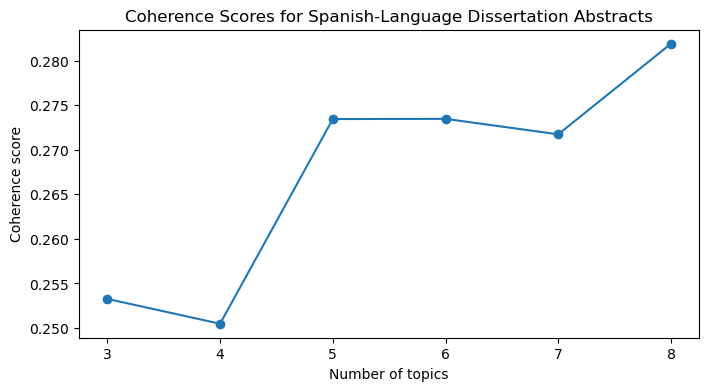

In [17]:
# Optional coherence sweep for Spanish-language dissertations with English abstracts

topic_counts = [3, 4, 5, 6, 7, 8]
coherence_scores = []

for num_topics in topic_counts:
    model = gensim.models.LdaMulticore(
        bow_corpus,
        num_topics=num_topics,
        id2word=dictionary,
        passes=10,
        workers=WORKERS,
        random_state=2026
    )

    coherence_model = CoherenceModel(
        model=model,
        texts=processed_docs,
        dictionary=dictionary,
        coherence="c_v"
    )

    score = coherence_model.get_coherence()
    coherence_scores.append(score)

    print(f"{num_topics} topics: coherence = {score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(topic_counts, coherence_scores, marker="o")
plt.xlabel("Number of topics")
plt.ylabel("Coherence score")
plt.title("Coherence Scores for Spanish-Language Dissertation Abstracts")
plt.show()


In [18]:
# Train the LDA model

print("Creating LDA model...")

lda_model = gensim.models.LdaMulticore(
    bow_corpus,
    num_topics=NUM_TOPICS,
    id2word=dictionary,
    passes=PASSES,
    workers=WORKERS,
    random_state=2026
)

print("Model created. Top terms by topic:")

for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")


Creating LDA model...
Model created. Top terms by topic:
Topic 0: 0.015*"dominican" + 0.012*"translat" + 0.009*"centuri" + 0.007*"spanish" + 0.006*"text" + 0.006*"cultur" + 0.006*"differ" + 0.006*"tradit" + 0.005*"critic" + 0.005*"edit"
Topic 1: 0.009*"author" + 0.008*"polit" + 0.007*"chapter" + 0.007*"novel" + 0.006*"narrat" + 0.006*"centuri" + 0.005*"text" + 0.005*"subject" + 0.005*"spanish" + 0.005*"critic"
Topic 2: 0.007*"writer" + 0.007*"narrat" + 0.007*"cultur" + 0.007*"state" + 0.007*"chapter" + 0.006*"first" + 0.006*"author" + 0.006*"literatur" + 0.005*"histor" + 0.005*"time"
Topic 3: 0.012*"cultur" + 0.009*"polit" + 0.008*"discours" + 0.007*"nation" + 0.006*"social" + 0.006*"literatur" + 0.006*"author" + 0.006*"narrat" + 0.005*"poet" + 0.005*"writer"
Topic 4: 0.023*"spanish" + 0.012*"languag" + 0.011*"chapter" + 0.008*"also" + 0.007*"novel" + 0.006*"author" + 0.006*"centuri" + 0.005*"american" + 0.005*"social" + 0.005*"analyz"


In [19]:
# Assign dominant topic to each Spanish-language dissertation abstract

topic_distributions = [lda_model[doc] for doc in bow_corpus]

def dominant_topic(topic_dist):
    if not topic_dist:
        return None
    return max(topic_dist, key=lambda x: x[1])[0]

spanish_model_data = spanish_model_data.copy()
spanish_model_data["dominant_topic"] = [
    dominant_topic(dist) for dist in topic_distributions
]

print(spanish_model_data["dominant_topic"].value_counts().sort_index())

spanish_model_data[["title", "year", "program", "dominant_topic", "abstract"]].head(10)


dominant_topic
0    21
1    52
2    45
3    37
4    41
Name: count, dtype: int64


,title,year,program,dominant_topic,abstract
1541,The Prose Poem at the Outset of the Modernist ...,1977.0,Spanish,2,The main purpose of the study is to trace the ...
2373,"""EL DONADO HABLADOR"", DE ALCALA YANEZ Y RIBERA...",1981.0,Spanish,1,Jeronimo de Alcala Yanez y Ribera (1571-1632) ...
2380,JUAN JOSE ARREOLA: TRAYECTORIA TEMATICA Y ESTI...,1981.0,Spanish,2,"Juan Jose Arreola, a Mexican writer born in 19..."
2414,"PRESENCIA, FUNCION Y MANEJO DEL MITO EN LA OBR...",1981.0,Spanish,1,The various modes in which myth manifests itse...
2429,EL SIGNO Y SU SEMIOSIS: DISCURSO POETICO DE OL...,1981.0,Spanish,1,The poetic discourse of Oliverio Girondo consi...
2791,EL ANTICLERICALISMO DE JOVELLANOS. (SPANISH TE...,1983.0,Spanish,1,The ideologies of a large group of enlightened...
3219,EL TEATRO DE VIRGILIO PINERA. (SPANISH TEXT).,1985.0,Spanish,2,Virgilio Pinera's major dramatic plays are rel...
3246,THE FAMILY AS A THEME IN SOME POETS OF THE GEN...,1985.0,Spanish,3,The group of writers that belongs to the Gener...
3432,"EL MICRO-RELATO EN MEXICO: JULIO TORRI, JUAN J...",1986.0,Spanish,1,An extremely brief short story (averaging abou...
3449,LA NARRATIVA DE LUIS RAFAEL SANCHEZ: TEXTO Y C...,1986.0,Spanish,3,The narrative work of Luis Rafael Sanchez is a...


## Topic Interpretation
## Topic Interpretation

Based on the top words and high-scoring example records, I interpreted the five topics as follows. These labels are interpretive rather than automatic. **I'll refine the topics analysis in the following cells.**

**Topic 0**  
Top words: dominican, translat, centuri, spanish, text, cultur, differ, tradit, critic, edit  
Interpretation: Translation, textual tradition, and Spanish-language cultural history

**Topic 1**  
Top words: author, polit, chapter, novel, narrat, centuri, text, subject, spanish, critic  
Interpretation: Subjectivity, politics, and narrative in Hispanic literature

**Topic 2**  
Top words: writer, narrat, cultur, state, chapter, first, author, literatur, histor, critic  
Interpretation: Narrative, cultural history, and state formation in Latin American contexts

**Topic 3**  
Top words: cultur, polit, discours, nation, social, literatur, author, narrat, poet, writer  
Interpretation: Culture, politics, nation, and social discourse

**Topic 4**  
Top words: spanish, languag, chapter, also, novel, author, centuri, american, latin, social  
Interpretation: Spanish language, sociolinguistics, and literary/social analysis

In [20]:
# Simple topic summary for interpretation

for topic_id in range(lda_model.num_topics):
    print(f"\n=== Topic {topic_id} ===")
    print("Top words:")
    print(", ".join([word for word, weight in lda_model.show_topic(topic_id, topn=10)]))

    topic_docs = []
    for doc_index, bow_doc in enumerate(bow_corpus):
        score = dict(lda_model.get_document_topics(bow_doc, minimum_probability=0))[topic_id]
        topic_docs.append((doc_index, score))

    top_docs = sorted(topic_docs, key=lambda x: x[1], reverse=True)[:10]

    print("\nExample titles:")
    for doc_index, score in top_docs:
        doc = spanish_model_data.iloc[doc_index]
        print(f"- {doc['title']} ({int(doc['year']) if pd.notna(doc['year']) else 'n.d.'})")


=== Topic 0 ===
Top words:
dominican, translat, centuri, spanish, text, cultur, differ, tradit, critic, edit

Example titles:
- Traduccion e interpretacion: Langston Hughes y Federico Garcia Lorca, encuentro en el lenguaje. (2007)
- Continuidad y cambio en los condicionantes lingüísticos y socio-demográficos del uso del pronombre sujeto en el español de la primera generación en Nueva York (2017)
- Mahoma en dos textos aljamiados del siglo XVI: La filosofía perenne y el monomito de los moriscos (2018)
- Traducciones y humanismo en la espana del siglo XV. (2004)
- A pilot study of a translated, culturally sensitive systemic lupus erythematosus self-help course for Latino lupus patients. (1994)
- El negro y el haitiano en la literatura dominicana de la diáspora (2018)
- The Dominican decima of popular tradition: An anthology, a classification of types and a study of its distinguishing features. (2003)
- Las <i>Letras</i> de Fernando de Pulgar, nueva edición, estudio preliminar y notas (2

In [21]:
# Topic summary using abstract snippets instead of titles

for topic_id in range(lda_model.num_topics):
    print(f"\n\n=== Topic {topic_id} ===")
    print("Top words:")
    print(", ".join([word for word, weight in lda_model.show_topic(topic_id, topn=10)]))

    topic_docs = []
    for doc_index, bow_doc in enumerate(bow_corpus):
        score = dict(lda_model.get_document_topics(bow_doc, minimum_probability=0))[topic_id]
        topic_docs.append((doc_index, score))

    top_docs = sorted(topic_docs, key=lambda x: x[1], reverse=True)[:5]

    print("\nRepresentative abstract snippets:")
    for doc_index, score in top_docs:
        doc = spanish_model_data.iloc[doc_index]
        abstract = str(doc["abstract"]).replace("\n", " ")

        print(f"\nScore: {score:.3f}")
        print(f"Title: {doc['title']}")
        print(f"Abstract snippet: {abstract[:700]}")



=== Topic 0 ===
Top words:
dominican, translat, centuri, spanish, text, cultur, differ, tradit, critic, edit

Representative abstract snippets:

Score: 0.996
Title: Traduccion e interpretacion: Langston Hughes y Federico Garcia Lorca, encuentro en el lenguaje.
Abstract snippet: This research project addresses the revision of prior canonical considerations leading to current theoretical principles of poetry translation. Until the last decade of the twentieth century, much of the debate regarding theory of translation opposed those considering it an unfeasible exercise against others who deemed translation of poetry as the essence or translation itself. These alternative points of view have been responsible for a new consideration of this literary endeavor in the last few years.;Aware of current issues on translation that combine parameters borrowed from the so-called literature of the margins and the connections between language, identity and nation, my project aims

Score: 0.996
Titl

In [23]:
pd.set_option("display.max_colwidth", 1000)

In [24]:
# Reader-friendly topic summary table with abstract snippets

summary_rows = []

for topic_id in range(lda_model.num_topics):
    top_words = ", ".join([word for word, weight in lda_model.show_topic(topic_id, topn=10)])

    topic_docs = []
    for doc_index, bow_doc in enumerate(bow_corpus):
        score = dict(lda_model.get_document_topics(bow_doc, minimum_probability=0))[topic_id]
        topic_docs.append((doc_index, score))

    top_docs = sorted(topic_docs, key=lambda x: x[1], reverse=True)[:5]

    for rank, (doc_index, score) in enumerate(top_docs, start=1):
        doc = spanish_model_data.iloc[doc_index]
        abstract = str(doc["abstract"]).replace("\n", " ")

        summary_rows.append({
            "topic": topic_id,
            "rank": rank,
            "score": round(score, 3),
            "top_words": top_words,
            "title": doc["title"],
            "abstract_snippet": abstract[:500]
        })

topic_summary_table = pd.DataFrame(summary_rows)
topic_summary_table

,topic,rank,score,top_words,title,abstract_snippet
0,0,1,0.996,"dominican, translat, centuri, spanish, text, cultur, differ, tradit, critic, edit","Traduccion e interpretacion: Langston Hughes y Federico Garcia Lorca, encuentro en el lenguaje.","This research project addresses the revision of prior canonical considerations leading to current theoretical principles of poetry translation. Until the last decade of the twentieth century, much of the debate regarding theory of translation opposed those considering it an unfeasible exercise against others who deemed translation of poetry as the essence or translation itself. These alternative points of view have been responsible for a new consideration of this literary endeavor in the last fe"
1,0,2,0.996,"dominican, translat, centuri, spanish, text, cultur, differ, tradit, critic, edit",Continuidad y cambio en los condicionantes lingüísticos y socio-demográficos del uso del pronombre sujeto en el español de la primera generación en Nueva York,"In situations of bilingualism in the United States, it has been shown that speakers who alter their grammar (syntax or morphology) are mostly second generation, that is, Latinos born in the United States (Flores-Ferrán 2004; Montrul 2004 ; Silva-Corvalán, 1994). Research about Spanish in the US shows that second generation speakers have different features from those of the first generation who are Latinos born in Latin America. However, is it possible that all the speakers of the first generatio"
2,0,3,0.996,"dominican, translat, centuri, spanish, text, cultur, differ, tradit, critic, edit",Mahoma en dos textos aljamiados del siglo XVI: La filosofía perenne y el monomito de los moriscos,"Besides highlighting the legitimacy of Islam, a religion that was prohibited by the Spanish Inquisition during the 1500’s, Aljamiado-Moriscoliterature has been distinguished by its secrecy, hybridity, ethnocentrism, proselytism, and emphasis on the chaotic reality of the clandestine social group considered to be the ""last Moors"" of Spain. The Spanish-Muslims or Moriscoswrote this underground literature in the Spanish language, utilizing Arabic characters. The work of historians and “moriscologis"
3,0,4,0.996,"dominican, translat, centuri, spanish, text, cultur, differ, tradit, critic, edit",Traducciones y humanismo en la espana del siglo XV.,"The relatively thin classical tradition in Spain during the Middle Ages was enriched in the fifteenth century through the contacts made by Spanish scholars and officials who traveled to Italian cities. This study focuses on one area of these new contacts with Italian humanism, namely texts in translation.;During the 1960s and 1970s there were repeated calls by scholars for a reinterpretation of the Spanish humanistic translations of the fifteenth century, in the face of the predominant attitude"
4,0,5,0.995,"dominican, translat, centuri, spanish, text, cultur, differ, tradit, critic, edit","A pilot study of a translated, culturally sensitive systemic lupus erythematosus self-help course for Latino lupus patients.","The Systemic Lupus Erythematosus Self-Help (SLESH) Course, a program of the National Arthritis Foundation, has been shown to be an effective self-management tool that provides knowledge and coping skills to people with lupus and their family members. However, many acknowledge that the program has largely failed to meet the needs of people from diverse cultural backgrounds particularly those who are non-English speaking or bilingual.;To address this need, a pilot study of a translated, culturally"
5,1,1,0.997,"author, polit, chapter, novel, narrat, centuri, text, subject, spanish, critic",El caso de Mateo Alemán: La interaccion entre el derecho y la literatura en el informe de la mina de mercurio de Almaden y <i>El Guzman de Alfarache</i>,"In 1593, the Judge Mateo Alemán was in charge of inspecting the quicksilver mines of Almadén in Spain to report on the situation of its workers, prisoners of the Crown, and

In [28]:
from IPython.display import display, Markdown

for topic_id in range(lda_model.num_topics):
    display(Markdown(f"## Topic {topic_id}"))
    display(Markdown(
        "**Top words:** " +
        ", ".join([word for word, weight in lda_model.show_topic(topic_id, topn=10)])
    ))

    topic_docs = []
    for doc_index, bow_doc in enumerate(bow_corpus):
        score = dict(lda_model.get_document_topics(bow_doc, minimum_probability=0))[topic_id]
        topic_docs.append((doc_index, score))

    top_docs = sorted(topic_docs, key=lambda x: x[1], reverse=True)[:3]

    for doc_index, score in top_docs:
        doc = spanish_model_data.iloc[doc_index]
        abstract = str(doc["abstract"]).replace("\n", " ")

        display(Markdown(f"""
**Score:** {score:.3f}  
**Title:** {doc["title"]}  
**Abstract snippet:** {abstract[:1200]}
"""))

## Topic 0

**Top words:** dominican, translat, centuri, spanish, text, cultur, differ, tradit, critic, edit


**Score:** 0.996  
**Title:** Traduccion e interpretacion: Langston Hughes y Federico Garcia Lorca, encuentro en el lenguaje.  
**Abstract snippet:** This research project addresses the revision of prior canonical considerations leading to current theoretical principles of poetry translation. Until the last decade of the twentieth century, much of the debate regarding theory of translation opposed those considering it an unfeasible exercise against others who deemed translation of poetry as the essence or translation itself. These alternative points of view have been responsible for a new consideration of this literary endeavor in the last few years.;Aware of current issues on translation that combine parameters borrowed from the so-called literature of the margins and the connections between language, identity and nation, my project aims not only to define a new standard for translation itself but also to create a canonical area for the translation of Federico Garcia Lorca by Langston Hughes, an American poet of the Harlem Renaissance.;Although acknowledging the existence of a liminal space for translations has not presented many obstacles, demonstrating the theoretical and literary values of my claim for Hughes' work has proven to be an intricate and often complex task. With some methodological inspiration found in the studies



**Score:** 0.996  
**Title:** Continuidad y cambio en los condicionantes lingüísticos y socio-demográficos del uso del pronombre sujeto en el español de la primera generación en Nueva York  
**Abstract snippet:** In situations of bilingualism in the United States, it has been shown that speakers who alter their grammar (syntax or morphology) are mostly second generation, that is, Latinos born in the United States (Flores-Ferrán 2004; Montrul 2004 ; Silva-Corvalán, 1994). Research about Spanish in the US shows that second generation speakers have different features from those of the first generation who are Latinos born in Latin America. However, is it possible that all the speakers of the first generation behave grammatically in the same way due to the fact of being born in Latin America regardless of the amount of years living in the country? This dissertation is a variationist study of Spanish in New York City that seeks to explore if the grammar of the newcomers and that of the established immigrants, who together make up the first generation, is modified like the grammar of the second generation speakers born in NYC. Through the study of the subject pronoun variable, this dissertation explores whether the hierarchies of variables and constraints are the same in these two groups coming to NYC from Latin America. For the purpose of this research, as in other sociolinguistics studies, firs



**Score:** 0.996  
**Title:** Mahoma en dos textos aljamiados del siglo XVI: La filosofía perenne y el monomito de los moriscos  
**Abstract snippet:** Besides highlighting the legitimacy of Islam, a religion that was prohibited by the Spanish Inquisition during the 1500’s, Aljamiado-Moriscoliterature has been distinguished by its secrecy, hybridity, ethnocentrism, proselytism, and emphasis on the chaotic reality of the clandestine social group considered to be the "last Moors" of Spain. The Spanish-Muslims or Moriscoswrote this underground literature in the Spanish language, utilizing Arabic characters. The work of historians and “moriscologists” such as L.P. Harvey, Luce López-Baralt, María Teresa Narváez, Vincent Barletta, among others, have examined the practical role and didactic value that —at various levels— these hybrid texts had for the 16thCentury Moriscos, how this secret community reacted to their manuscripts, and in what way these documents helped them to strengthen their Islamic faith and identity. However, the interdisciplinary and theoretical approach followed by scholars in the field of Aljamiadostudies, have not explored in depth the possible role that the concept of Transcendence (or the existence beyond the physical level) had among the Crypto-Muslims during the 1500’s. The conception that humans can inhabit in


...

## Topic 4

**Top words:** spanish, languag, chapter, also, novel, author, centuri, american, social, analyz


**Score:** 0.998  
**Title:** Marginalidad y subversión en tres novelas de Juan Filloy de la década de 1930  
**Abstract snippet:** This dissertation focuses on the concepts of marginality and subversion in three novels written by Juan Filloy in the 1930s: ¡Estafen! (1932), Op Oloop (1934) and Caterva (1937). I study these novels in the context of the avant-garde movement of the 1920s and 1930s. I analyze the transformation that the concepts of marginality and subversion undergo when they are explored within the context of the avant-garde aesthetics, instead of that of social realism. I contrast Filloy’s approach to these themes with those of the novelists of the preceding decades. More importantly, I compare and contrast Filloy’s novels to Roberto Arlt’s El jueguete rabioso (1926) and Los siete locos (1929). I argue that Roberto Arlt’s novels influenced Juan Filloy’s novels, in regards to the subject matter and characters. Both Arlt and Filloy create characters that position themselves on the margins of society. However, Arlt’s characters come from the margins of society, and from there they attempt to subvert the status quo; they find themselves without the means to change their lives and resort to crime as their only possibility. They aspire to subvert the status quo in order to overcome their marginalizatio



**Score:** 0.996  
**Title:** Densidad léxica en la prensa hispana de EE.UU. e Hispanoamérica: Un estudio comparativo  
**Abstract snippet:** This dissertation focuses on a quantitative and comparative analysis of lexical density in Spanish print news in the United States and Latin America. Lexical density is the statistical measure that calculates the percentage of terms in relation to the total number of running words contained in a text. Within the context of Spanish in the United States, questions arise pertaining to the level of lexical compatibility and variability in contact situations, as well as in situations where the convergence of different varieties of the Spanish language coexist. Because most existing lexical density studies of Spanish media are descriptive, there is a need for comparative studies in lexical density to provide a better understanding of the use of written journalistic Spanish in both monolingual and language contact situations. This research quantifies, analyzes and compares the lexical inventories of the six most circulated Spanish newspapers published the United States and Latin America by focusing on three thematic contents: information, editorials and sports. Our corpora is comprised of at least 1,200 running words a day per content per newspaper, gathered over the course of six consecu



**Score:** 0.996  
**Title:** Glotopolítica de la Desigualdad: Ideologías del Mapudungun y el Español en Chile (2009–2019)  
**Abstract snippet:** Glottopolitics of Inequality: Ideologies on Mapudungun and Spanish in Chile (2009-2019) by Gabriel Alvarado Pavez Advisor: José del Valle This dissertation is an attempt to analyze contemporary discourses on Mapudungun and Spanish and their development within the political and economic context of Chile between 2009 and 2019. The object of analysis is the diverse array of linguistic ideologies displayed on both the hegemonic press (newspapers of nationwide circulation) and on Facebook, which helps provide a sociolinguistic profile of Chile from a glottopolitical perspective. This entails a point of view focused on power structures and their modes of (re)production and perpetuation, i.e. beyond the mere description of inequalities. Among the ideological frameworks detected here, there are some which had been previously described from the fields of linguistic anthropology and critical sociolinguistics, such as anonymity, authenticity, pride and profit. In the case of Mapudungun, other representations were also found, such as a vision of the language as sacred or untouchable, and cosmovisionism, that is, an attribution of metaphysical properties that depend on a unique connection betwe



**TOPICS** 

**Topic 0: Translation, textual tradition, and Spanish-language cultural history**

translat, text, edit → translation, textual editing, textual analysis
centuri, tradit → historical/literary tradition
spanish, cultur → Spanish-language cultural/literary context
dominican → Dominican literature/culture 
differ → difference, cultural difference, linguistic difference, or comparative analysis

**Topic 1: Subjectivity, politics, and narrative in Hispanic literature**

author, text, critic, chapter → scholarly literary analysis
novel, narrat → narrative fiction / novels
polit → political themes
centuri, spanish → historical Spanish/Hispanic literature
subject → subjectivity, identity, political subject, colonial subject 

**Topic 2: Literature, history, and state formation in Latin American contexts**

writer, author, literatur, critic → literary authorship, writers, and criticism
narrat → narrative form and storytelling
cultur, histor → cultural and historical analysis
state → the state, state power, state formation

**Topic 3: Culture, politics, nation, and social discourse**

cultur, social → cultural and social analysis
polit, nation → politics, nationhood, and national identity
discours → discourse, ideology, or public language
literatur, author, writer, poet → literary authors, writers, and poetry
narrat → narrative form

**Topic 4: Spanish language, sociolinguistics, and literary/social analysis**

spanish, languag → Spanish language and language study
american, latin → Latin American context
novel, author, centuri → literary history, novels, authors, historical periods
social → social themes or social analysis


In [29]:
# Investigate "subject" in Topic 1 abstracts

import re

topic_id = 1

topic1_scores = []
for doc_index, bow_doc in enumerate(bow_corpus):
    score = dict(lda_model.get_document_topics(bow_doc, minimum_probability=0))[topic_id]
    topic1_scores.append((doc_index, score))

top_topic1 = sorted(topic1_scores, key=lambda x: x[1], reverse=True)[:20]

topic1_examples = spanish_model_data.iloc[[idx for idx, score in top_topic1]].copy()
topic1_examples["topic_1_score"] = [score for idx, score in top_topic1]

def subject_context(text, window=120):
    matches = re.findall(rf".{{0,{window}}}\bsubject\w*\b.{{0,{window}}}", str(text), flags=re.I)
    return " ... ".join(matches[:3])

topic1_examples["subject_context"] = topic1_examples["abstract"].apply(subject_context)

topic1_examples[["topic_1_score", "title", "subject_context"]]

,topic_1_score,title,subject_context
15717,0.997435,El caso de Mateo Alemán: La interaccion entre el derecho y la literatura en el informe de la mina de mercurio de Almaden y <i>El Guzman de Alfarache</i>,"t his task. The judge sides against a punitive technic, half way between the Medieval and Modern periods, that uses the subjects in benefit of society, forming docile bodies, needed in times of war and threaten by loss of international political po ... ions that aims to reach the specific purpose that the Report never attained. The novel uses the Law to present this new subject, product of an emergent modern society that exposes his case, using a forensic terminology, with the aim of denouncing"
14109,0.996929,Origén e influencia de la figura de Simón Bolívar en los escritores modernistas hispanoamericanos,
2414,0.996381,"PRESENCIA, FUNCION Y MANEJO DEL MITO EN LA OBRA DEL INCA GARCILASO DE LA VEGA. (SPANISH TEXT).","dged as a uniform element with identical functions within diverse frameworks. It is obvious that myth is not a coherent subject, but for this very reason it is susceptible of multifold approaches, even contradictory ones.;In recent years the term"
12540,0.996049,Free love in Montevideo. Roberto de las Carreras and the development of erotic anarchism in 1900,"ship of the dandy with commodities as an alternative to market economy and as a quest for tentative approaches to queer subjectivities.;The third chapter examines the idea of free love as embraced by the anarchist movement, which De las Carreras' pornogr"
2429,0.995928,EL SIGNO Y SU SEMIOSIS: DISCURSO POETICO DE OLIVERIO GIRONDO. (SPANISH TEXT).,";Espantapajaros, published in 1932, represents, with its use of prose poems, the transition from a critique of both the subject and the object to a critique of language itself. Read as a metonym of Le cornet a des of Max Jacob, Espantapajaros valu"
12538,0.995884,De la peninsula Iberica a Italia: Concepcion y practica teatral de las primeras comedias castellanas,
6468,0.995537,"Dialectica, diferencia y complementaridad en el sujeto colonial y ""mestizo"". Caso: Inca Garcilaso de la Vega.","e private and public spheres of the new colonial society. These new conditions forced the transformation of the Spanish subject and the process of its formation. This new colonial relationship imposed by Spain on America allowed and, in some cases ... , forced the emergence of a new type of subjectivities, which at the same time, were the result of the positions the new subjects assumed in different contexts and historical ... situations.;The first part of this study addresses the problem of the emergence of the colonial subject in Spain and America during the XVI and XVII centuries. It takes into consideration diverse material and ideological fa"
14542,0.995507,El Spill de Jaume Roig. Estudio de relaciones semióticas con la picaresca,
16549,0.995404,Auto®Ficción Latinx de Nueva York (1999–2020),"decades of the 21st Century. For these authors, their life experiences and quotidian uses of this city’s spaces are the subjects of their work. Auto®ficción draws attention not only to the mixing of genres and hybrid nature of these works, but also"
17932,0.995296,Alianzas Antimodernas: Estudios del Cine Español del Proceso 15M,


In [55]:
# Readable topic labels and words for visualization

topic_labels = {
    0: "Translation & textual tradition",
    1: "Subjectivity, politics & narrative",
    2: "Literature, history & political change",
    3: "Culture, politics & nation",
    4: "Spanish language & sociolinguistics",
}

topic_readable_words = {
    0: ["Dominican", "translation", "century", "Spanish", "text", "culture", "difference", "tradition", "criticism", "editing"],
    1: ["author", "politics", "chapter", "novel", "narrative", "century", "text", "subjectivity", "Spanish", "criticism"],
    2: ["writer", "narrative", "culture", "state", "chapter", "first", "author", "literature", "history", "criticism"],
    3: ["culture", "politics", "discourse", "nation", "social", "literature", "author", "narrative", "poetry", "writer"],
    4: ["Spanish", "language", "chapter", "also", "novel", "author", "century", "American", "Latin", "social"],
}

generic_words = {"chapter", "also", "first"}

topic_visual_words = {
    topic: [word for word in words if word not in generic_words]
    for topic, words in topic_readable_words.items()
}

In [56]:
generic_words = {"chapter", "also", "first"}

topic_visual_words = {
    topic: [word for word in words if word not in generic_words]
    for topic, words in topic_readable_words.items()
}

In [57]:
import urllib.request

url = "https://cdn.jsdelivr.net/npm/d3@7/dist/d3.min.js"
req = urllib.request.Request(
    url,
    headers={"User-Agent": "Mozilla/5.0"}
)

d3_source = urllib.request.urlopen(req).read().decode("utf-8")
print("D3 downloaded:", len(d3_source), "characters")

D3 downloaded: 279703 characters


In [73]:
# D3.js visualization of topics and words

import json
from IPython.display import IFrame

nodes = []
links = []
seen = set()

for topic_id, words in topic_visual_words.items():
    topic_label = topic_labels[topic_id]

    if topic_label not in seen:
        nodes.append({
            "id": topic_label,
            "type": "topic",
            "group": topic_id
        })
        seen.add(topic_label)

    for word in words:
        if word not in seen:
            nodes.append({
                "id": word,
                "type": "word",
                "group": topic_id
            })
            seen.add(word)

        links.append({
            "source": topic_label,
            "target": word
        })

graph_data = {"nodes": nodes, "links": links}

html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<script>{d3_source}</script>
<style>
  body {{
    font-family: Helvetica, Arial, sans-serif;
    margin: 0;
    background: #FFFCF2;
  }}
  .link {{
    stroke: #b7a4e0;
    stroke-opacity: 0.35;
    stroke-width: 1.5px;
  }}
  .label {{
    font-size: 12px;
    pointer-events: none;
  }}
</style>
</head>
<body>
<svg width="1400" height="1000"></svg>

<script>
const graph = {json.dumps(graph_data)};

const svg = d3.select("svg");
svg.style("background", "#FFFCF2");
const width = +svg.attr("width");
const height = +svg.attr("height");

const simulation = d3.forceSimulation(graph.nodes)
  .force("link", d3.forceLink(graph.links).id(d => d.id).distance(130))
  .force("charge", d3.forceManyBody().strength(-450))
  .force("center", d3.forceCenter(width / 2, height / 2))
  .force("collision", d3.forceCollide().radius(d => d.type === "topic" ? 95 : 45));

const link = svg.append("g")
  .selectAll("line")
  .data(graph.links)
  .join("line")
  .attr("class", "link");

const node = svg.append("g")
  .selectAll("g")
  .data(graph.nodes)
  .join("g")
  .call(drag(simulation));

node.filter(d => d.type === "word")
  .append("circle")
  .attr("r", 36)
  .attr("fill", "#F6E96B")
  .attr("fill-opacity", 0.75)
  .attr("stroke", "#A89F2D")
  .attr("stroke-width", 1);

node.filter(d => d.type === "topic")
  .append("rect")
  .attr("x", -110)
  .attr("y", -26)
  .attr("width", 240)
  .attr("height", 50)
  .attr("rx", 16)
  .attr("fill", "#D8CCF0")
  .attr("fill-opacity", 0.75)
  .attr("stroke", "#7B68A8")
  .attr("stroke-width", 0.8);

const label = svg.append("g")
  .selectAll("text")
  .data(graph.nodes)
  .join("text")
  .attr("class", "label")
  .attr("text-anchor", "middle")
  .attr("dominant-baseline", "middle")
  .attr("fill", "#2F2F2F")
  .attr("font-weight", "501")
  .text(d => d.id);

simulation.on("tick", () => {{
  const margin = 110;

  graph.nodes.forEach(d => {{
    d.x = Math.max(margin, Math.min(width - margin, d.x));
    d.y = Math.max(margin, Math.min(height - margin, d.y));
  }});

  link
    .attr("x1", d => d.source.x)
    .attr("y1", d => d.source.y)
    .attr("x2", d => d.target.x)
    .attr("y2", d => d.target.y);

 node
  .attr("transform", d => "translate(" + d.x + "," + d.y + ")");

  label
    .attr("x", d => d.x)
    .attr("y", d => d.y);
}});

function drag(simulation) {{
  return d3.drag()
    .on("start", event => {{
      if (!event.active) simulation.alphaTarget(0.3).restart();
      event.subject.fx = event.subject.x;
      event.subject.fy = event.subject.y;
    }})
    .on("drag", event => {{
      event.subject.fx = event.x;
      event.subject.fy = event.y;
    }})
    .on("end", event => {{
      if (!event.active) simulation.alphaTarget(0);
      event.subject.fx = null;
      event.subject.fy = null;
    }});
}}
</script>
</body>
</html>
"""

with open("topic_d3_network.html", "w", encoding="utf-8") as f:
    f.write(html)

IFrame("topic_d3_network.html", width=1050, height=800)

Topic 1
author, text, critic, chapter → scholarly literary analysis



Topic 1
author, text, critic, chapter → scholarly literary analysis



Topic 1
author, text, critic, chapter → scholarly literary analysis



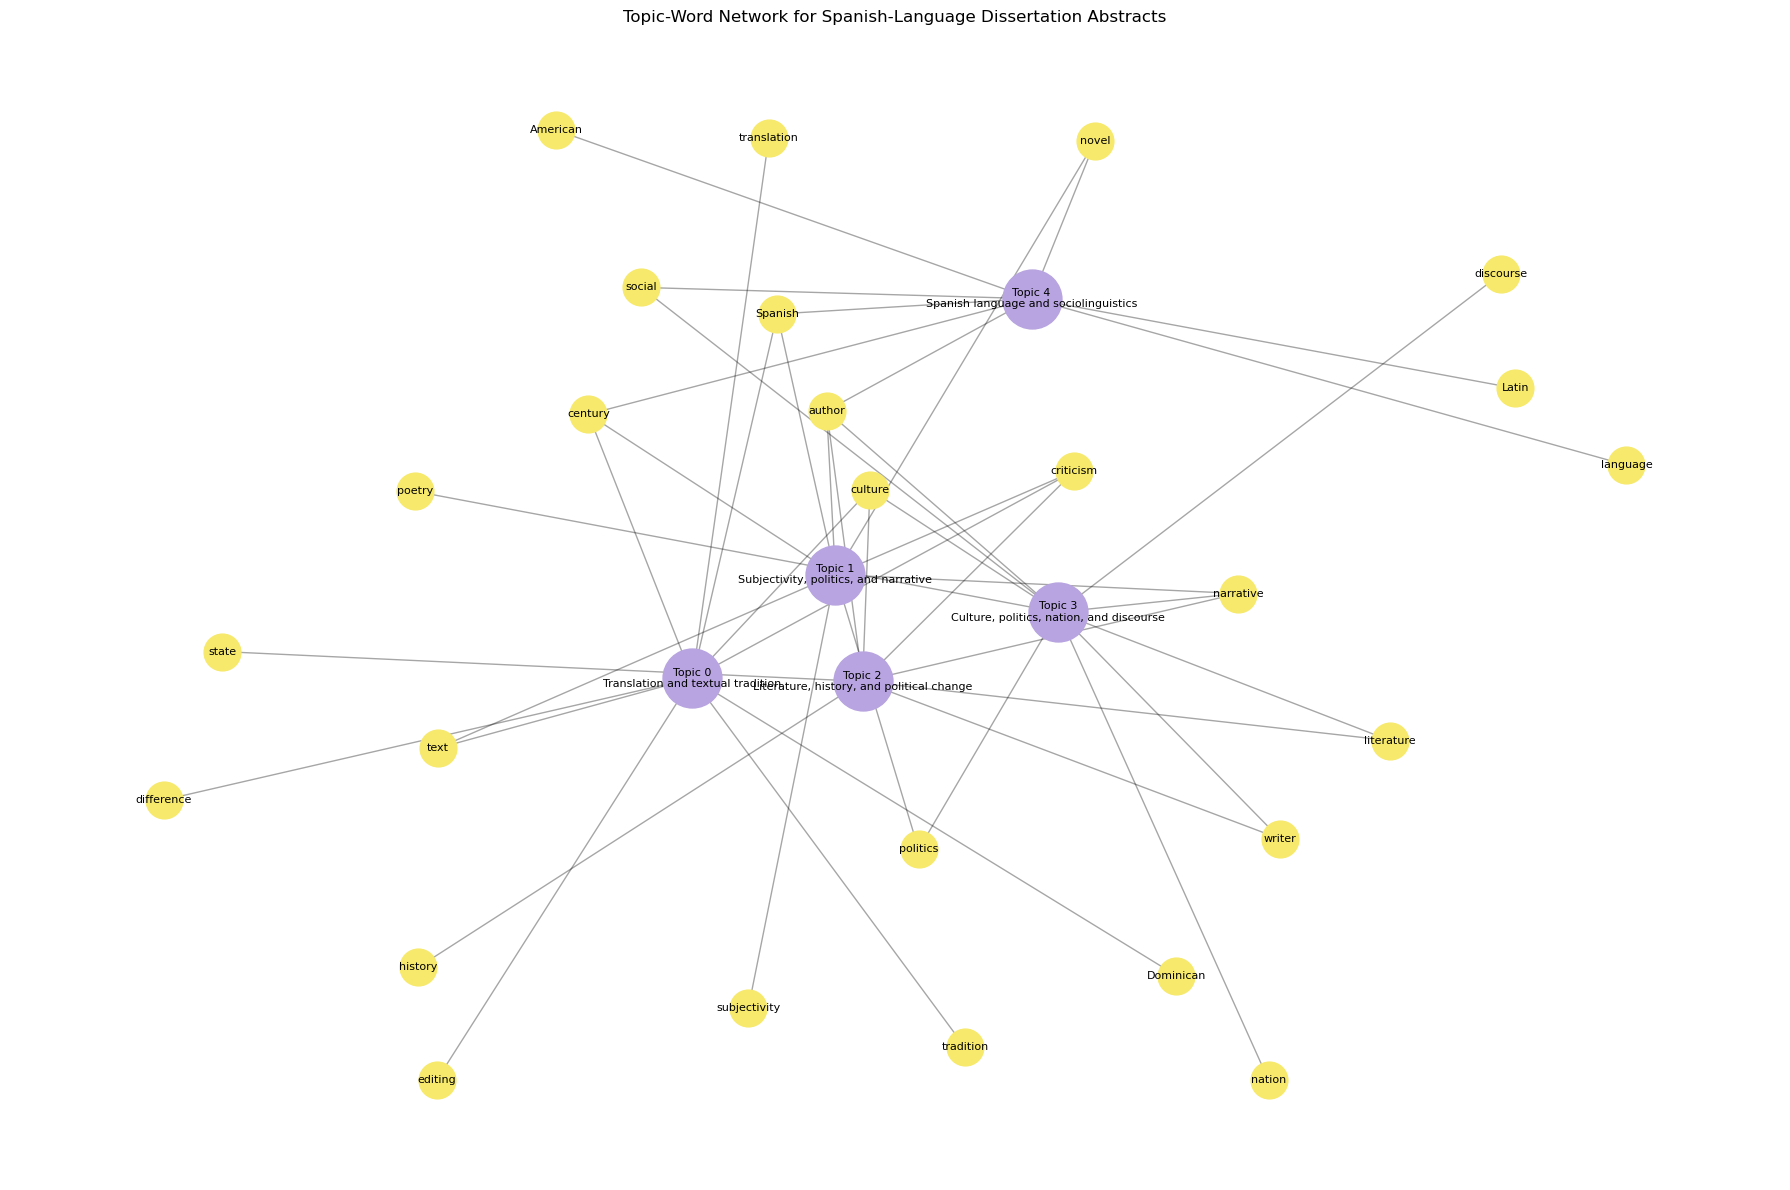

In [38]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Add topic and word nodes
for topic_id, words in topic_visual_words.items():
    topic_node = f"Topic {topic_id}"
    G.add_node(topic_node, node_type="topic", label=topic_labels[topic_id])

    for word in words:
        G.add_node(word, node_type="word", label=word)
        G.add_edge(topic_node, word)

# Layout
pos = nx.spring_layout(G, seed=2026, k=0.9)

# pos["Topic 0"] = (-0.5, 0.2)
# pos["Topic 1"] = (1.2, 0.8)
# pos["Topic 2"] = (-1.2, -0.2)
# pos["Topic 3"] = (1.2, -0.2)
# pos["Topic 4"] = (0.0, -1.0)

topic_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "topic"]
word_nodes = [n for n, d in G.nodes(data=True) if d["node_type"] == "word"]

plt.figure(figsize=(18, 12))

nx.draw_networkx_edges(G, pos, alpha=0.35)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=topic_nodes,
    node_color="#B7A4E0",
    node_size=1800,
    label="Topics"
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=word_nodes,
    node_color="#F6E96B",
    node_size=700,
    label="Words"
)

labels = {
    node: node if node in word_nodes else f"{node}\n{topic_labels[int(node.split()[1])]}"
    for node in G.nodes()
}

nx.draw_networkx_labels(G, pos, labels=labels, font_size=8)

plt.title("Topic-Word Network for Spanish-Language Dissertation Abstracts")
plt.axis("off")
plt.tight_layout()
plt.show()

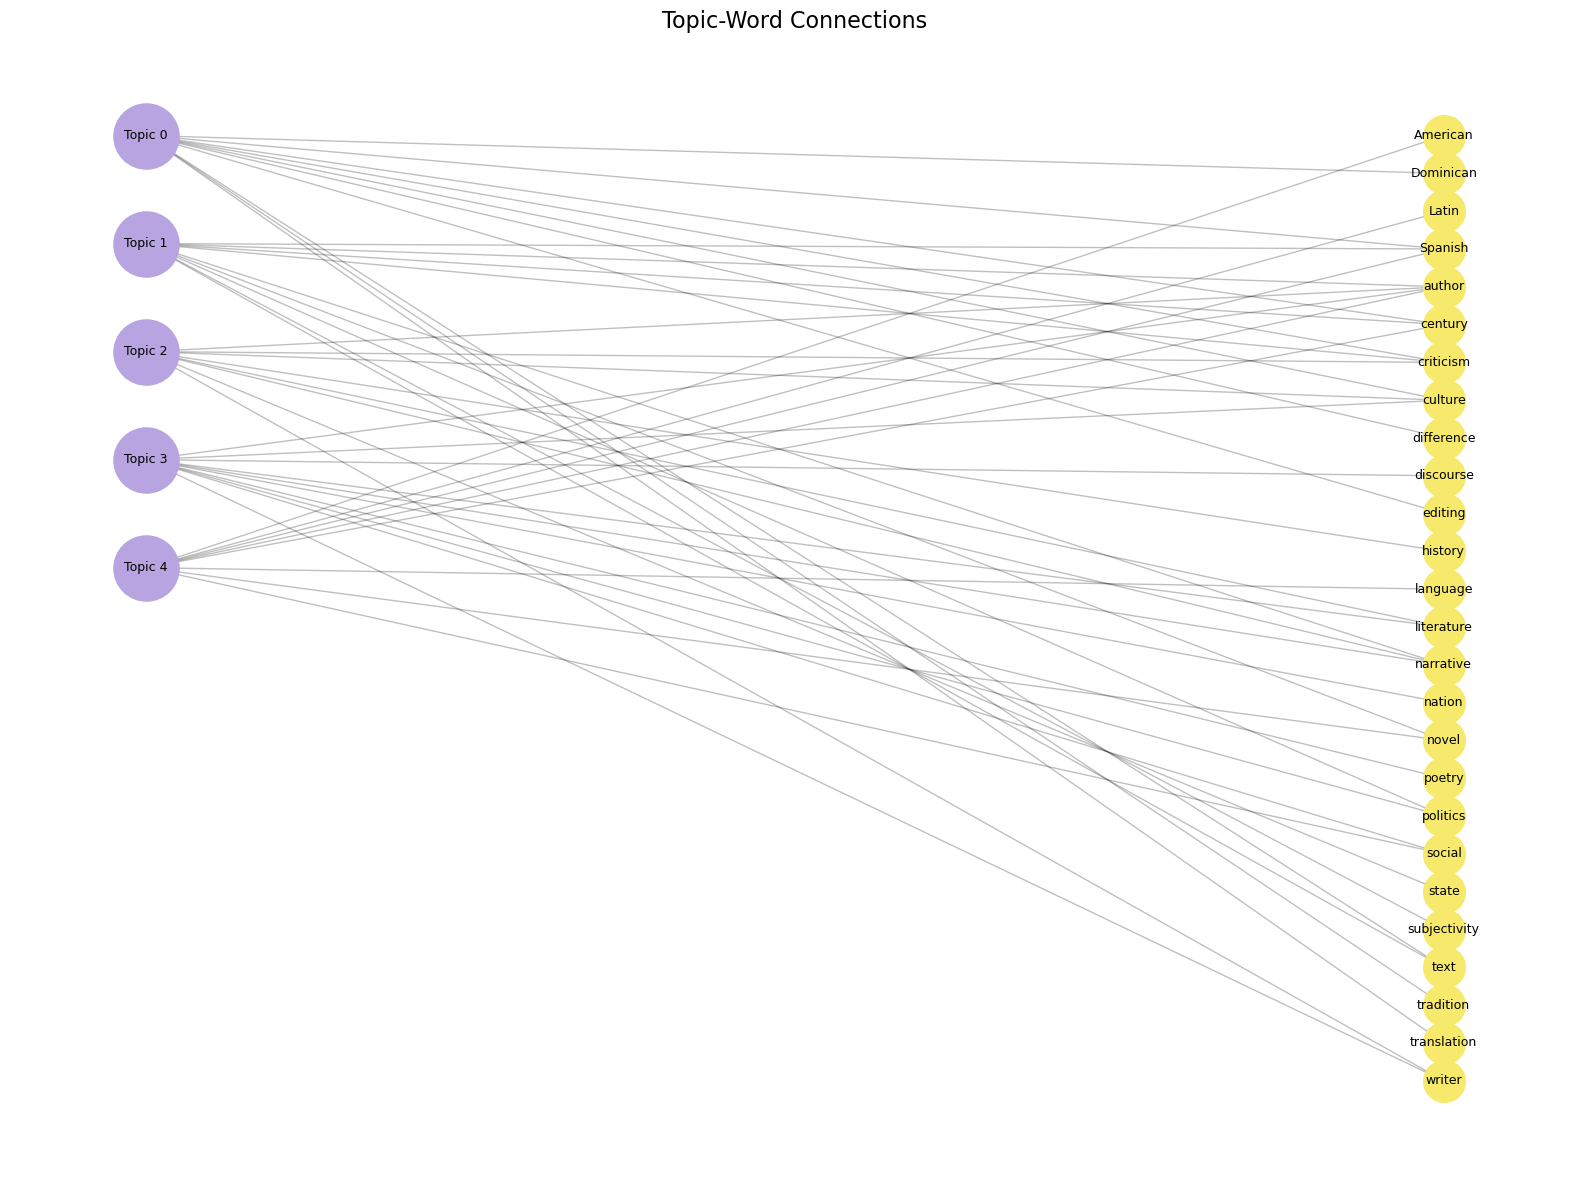

In [39]:
# import networkx as nx
# import matplotlib.pyplot as plt

# G = nx.Graph()

for topic_id, words in topic_visual_words.items():
    topic_node = f"Topic {topic_id}"
    G.add_node(topic_node, node_type="topic")

    for word in words:
        G.add_node(word, node_type="word")
        G.add_edge(topic_node, word)

topic_nodes = [f"Topic {i}" for i in topic_visual_words.keys()]
word_nodes = sorted([n for n, d in G.nodes(data=True) if d["node_type"] == "word"])

# Manual two-column layout
pos = {}

for i, topic in enumerate(topic_nodes):
    pos[topic] = (0, -i)

for i, word in enumerate(word_nodes):
    pos[word] = (2.8, -i * 0.35)

plt.figure(figsize=(16, 12))

nx.draw_networkx_edges(G, pos, alpha=0.25, width=1)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=topic_nodes,
    node_color="#B7A4E0",
    node_size=2200
)

nx.draw_networkx_nodes(
    G, pos,
    nodelist=word_nodes,
    node_color="#F6E96B",
    node_size=900
)

labels = {node: node for node in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=9)

plt.title("Topic-Word Connections", fontsize=16)
plt.axis("off")
plt.tight_layout()
plt.show()

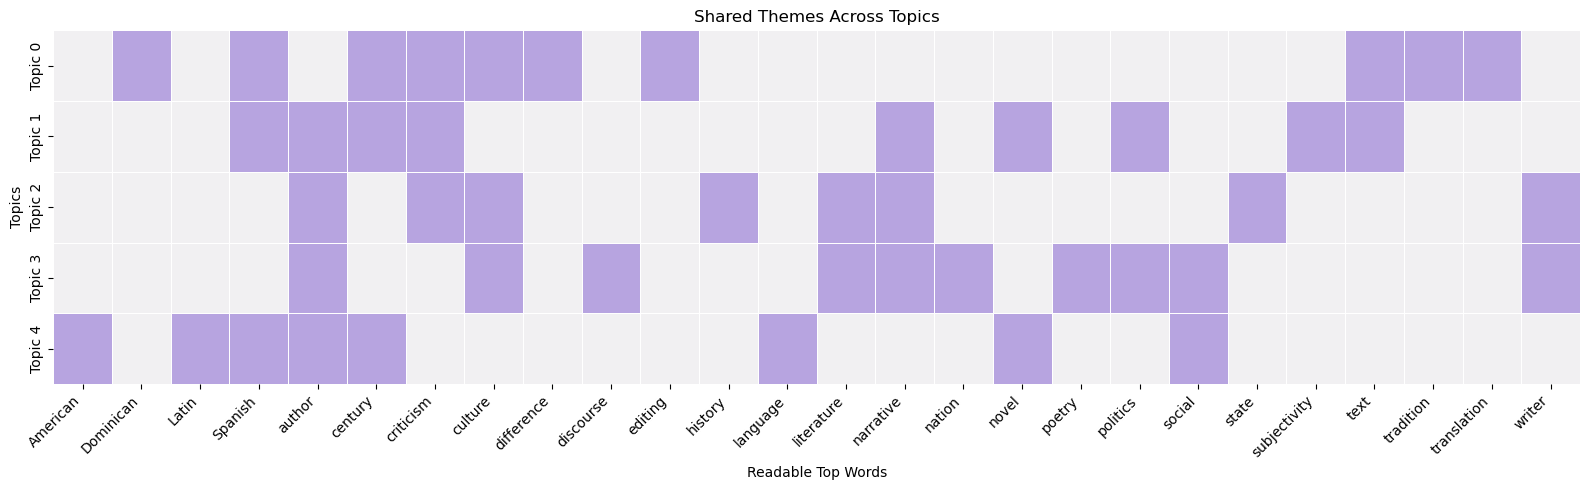

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Build topic-word matrix
all_words = sorted(set(word for words in topic_visual_words.values() for word in words))

matrix = pd.DataFrame(0, index=[f"Topic {i}" for i in topic_visual_words], columns=all_words)

for topic_id, words in topic_visual_words.items():
    for word in words:
        matrix.loc[f"Topic {topic_id}", word] = 1

plt.figure(figsize=(16, 5))
sns.heatmap(
    matrix,
    cmap=sns.light_palette("#B7A4E0", as_cmap=True),
    linewidths=0.5,
    linecolor="white",
    cbar=False
)

plt.title("Shared Themes Across Topics")
plt.xlabel("Readable Top Words")
plt.ylabel("Topics")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

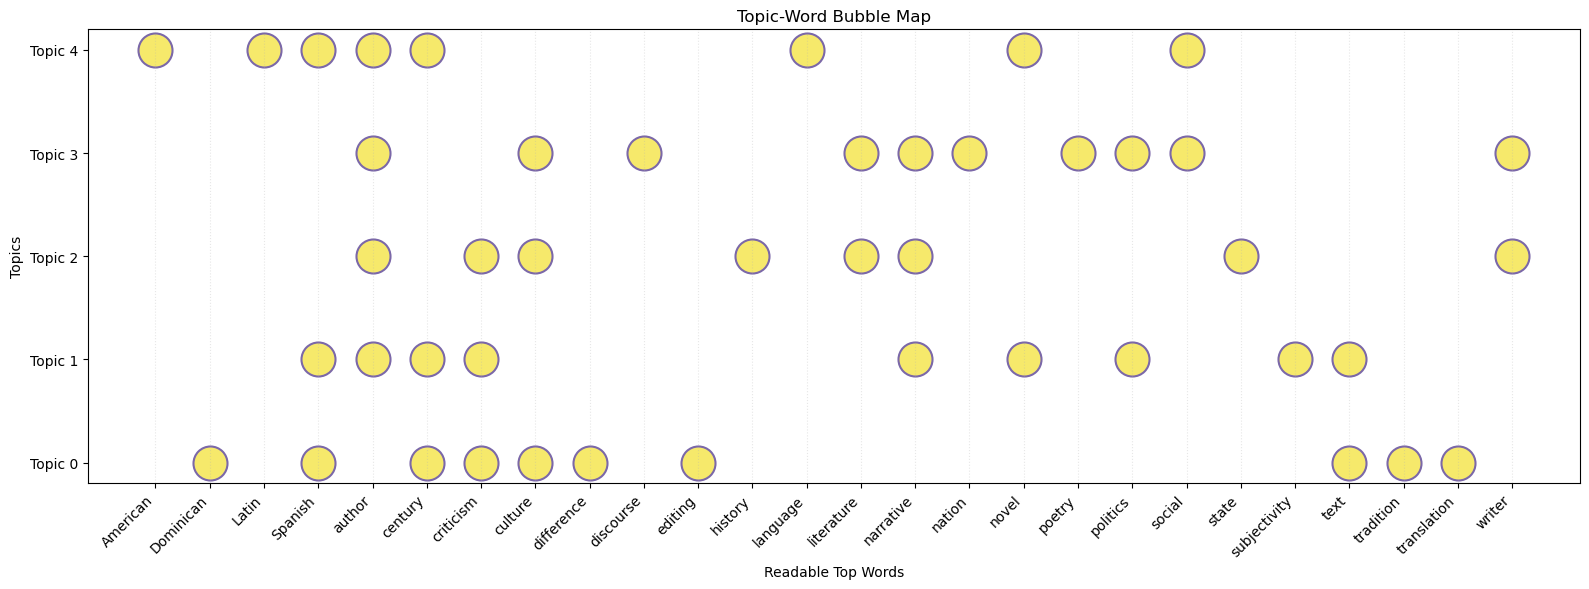

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

bubble_rows = []

for topic_id, words in topic_visual_words.items():
    for word in words:
        bubble_rows.append({
            "topic": f"Topic {topic_id}",
            "word": word
        })

bubble_df = pd.DataFrame(bubble_rows)

topics = sorted(bubble_df["topic"].unique())
words = sorted(bubble_df["word"].unique())

topic_to_y = {topic: i for i, topic in enumerate(topics)}
word_to_x = {word: i for i, word in enumerate(words)}

bubble_df["x"] = bubble_df["word"].map(word_to_x)
bubble_df["y"] = bubble_df["topic"].map(topic_to_y)

plt.figure(figsize=(16, 6))

plt.scatter(
    bubble_df["x"],
    bubble_df["y"],
    s=600,
    color="#F6E96B",
    edgecolor="#7B68A8",
    linewidth=1.5
)

plt.xticks(range(len(words)), words, rotation=45, ha="right")
plt.yticks(range(len(topics)), topics)

plt.title("Topic-Word Bubble Map")
plt.xlabel("Readable Top Words")
plt.ylabel("Topics")

plt.grid(axis="x", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

In [43]:
import plotly.graph_objects as go

# Optional shorter theme labels for Sankey
topic_theme_labels = {
    0: "Translation & textual tradition",
    1: "Subjectivity & political narrative",
    2: "Literature, history & political change",
    3: "Culture, nation & discourse",
    4: "Language & sociolinguistics",
}

nodes = []
node_index = {}

def add_node(label):
    if label not in node_index:
        node_index[label] = len(nodes)
        nodes.append(label)
    return node_index[label]

sources = []
targets = []
values = []
colors = []

for topic_id, words in topic_visual_words.items():
    topic_label = f"Topic {topic_id}"
    theme_label = topic_theme_labels[topic_id]

    topic_idx = add_node(topic_label)
    theme_idx = add_node(theme_label)

    sources.append(topic_idx)
    targets.append(theme_idx)
    values.append(len(words))
    colors.append("rgba(183, 164, 224, 0.45)")  # lavender

    for word in words:
        word_idx = add_node(word)

        sources.append(theme_idx)
        targets.append(word_idx)
        values.append(1)
        colors.append("rgba(246, 233, 107, 0.55)")  # lemon yellow

fig = go.Figure(data=[go.Sankey(
    arrangement="snap",
    node=dict(
        pad=20,
        thickness=18,
        line=dict(color="rgba(80,80,80,0.3)", width=0.5),
        label=nodes,
        color=[
            "#B7A4E0" if label.startswith("Topic")
            else "#C9B8F2" if label in topic_theme_labels.values()
            else "#F6E96B"
            for label in nodes
        ]
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=colors
    )
)])

fig.update_layout(
    title_text="Topic, Theme, and Word Connections",
    font_size=12,
    width=1000,
    height=700
)

fig.show()

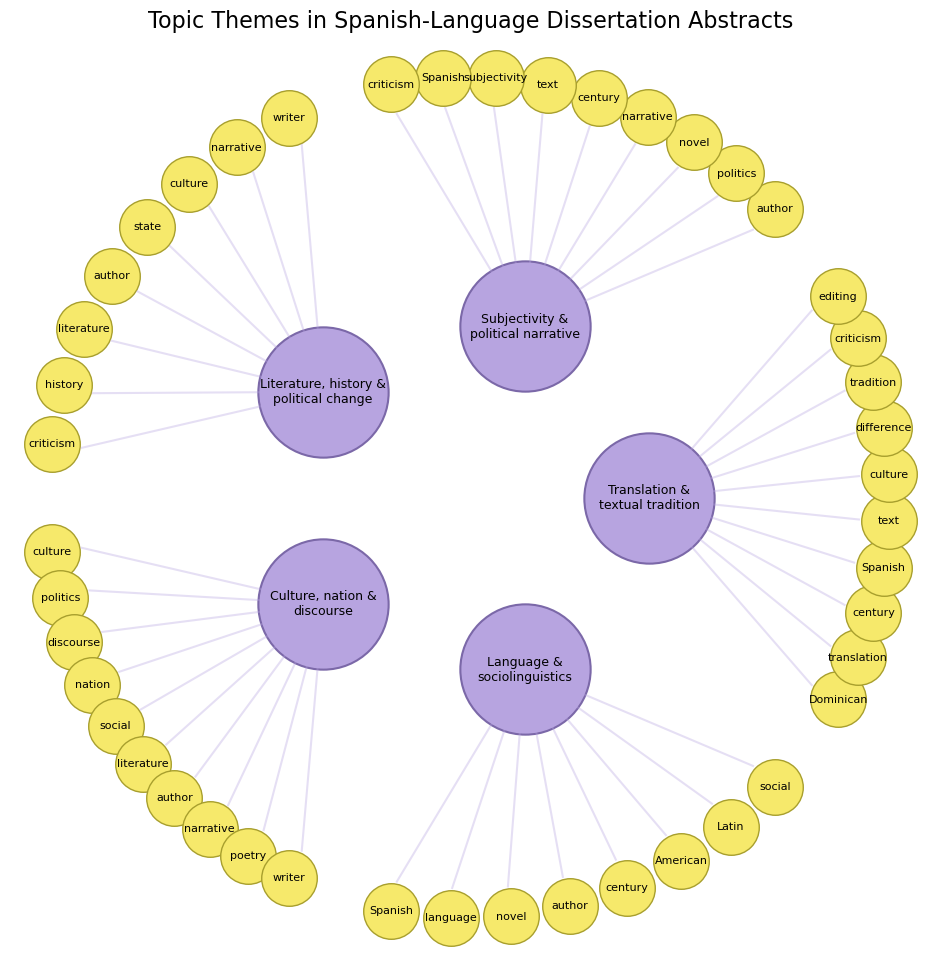

In [82]:
import matplotlib.pyplot as plt
import numpy as np

topic_theme_labels = {
    0: "Translation &\ntextual tradition",
    1: "Subjectivity &\npolitical narrative",
    2: "Literature, history &\npolitical change",
    3: "Culture, nation &\ndiscourse",
    4: "Language &\nsociolinguistics",
}

fig, ax = plt.subplots(figsize=(12, 12))
ax.set_aspect("equal")
ax.axis("off")

center_radius = 1.8
word_radius = 4.2

topic_angles = np.linspace(0, 2 * np.pi, len(topic_visual_words), endpoint=False)

for angle, topic_id in zip(topic_angles, topic_visual_words.keys()):
    topic_x = center_radius * np.cos(angle)
    topic_y = center_radius * np.sin(angle)

    ax.scatter(topic_x, topic_y, s=8800, color="#B7A4E0", edgecolor="#7B68A8", linewidth=1.5) # topic node
    ax.text(topic_x, topic_y, topic_theme_labels[topic_id], ha="center", va="center", fontsize=9)

    words = topic_visual_words[topic_id]
    word_angles = np.linspace(angle - 0.5, angle + 0.5, len(words))

    for word_angle, word in zip(word_angles, words):
        word_x = word_radius * np.cos(word_angle)
        word_y = word_radius * np.sin(word_angle)

        # ax.plot([topic_x, word_x], [topic_y, word_y], color="#B7A4E0", alpha=0.35) 
        # Stop the connector before the center of the word circle
        line_end_radius = word_radius - 0.30
        line_end_x = line_end_radius * np.cos(word_angle)
        line_end_y = line_end_radius * np.sin(word_angle)

        ax.plot([topic_x, line_end_x], [topic_y, line_end_y], color="#B7A4E0", alpha=0.35)
        ax.scatter(word_x, word_y, s=1600, color="#F6E96B", edgecolor="#A89F2D", linewidth=1) #word node
        ax.text(word_x, word_y, word, ha="center", va="center", fontsize=8)

plt.title("Topic Themes in Spanish-Language Dissertation Abstracts", fontsize=16)
plt.savefig("topic_theme_map.svg", format="svg", bbox_inches="tight")
plt.savefig("topic_theme_map.png", dpi=300, bbox_inches="tight")
plt.show()